In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("data/superstore.csv.csv")

In [14]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/16,6/16/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/15,10/18/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
df.shape

(9994, 21)

In [16]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [17]:
df.dtypes

row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub_category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

In [18]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [21]:
df.select_dtypes(include='number').mean()

row_id          4997.500000
postal_code    55190.379428
sales            229.858001
quantity           3.789574
discount           0.156203
profit            28.656896
dtype: float64

In [22]:
df.select_dtypes(include='number').median()

row_id          4997.5000
postal_code    56430.5000
sales             54.4900
quantity           3.0000
discount           0.2000
profit             8.6665
dtype: float64

In [23]:
df.select_dtypes(include='number').mode().iloc[0]

row_id             1.00
postal_code    10035.00
sales             12.96
quantity           3.00
discount           0.00
profit             0.00
Name: 0, dtype: float64

In [24]:
df.select_dtypes(include='number').std()

row_id          2885.163629
postal_code    32063.693350
sales            623.245101
quantity           2.225110
discount           0.206452
profit           234.260108
dtype: float64

In [25]:
df['order_date'] = pd.to_datetime(df['order_date'])

C:\Users\ajinkya bhalerao\AppData\Local\Temp\ipykernel_12860\2765250300.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'])


In [26]:
df['order_date'].dtype

dtype('<M8[ns]')

In [27]:
df['Month'] = df['order_date'].dt.to_period('M')

In [28]:
df[['order_date', 'Month']].head()

,order_date,Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [29]:
monthly_sales = df.groupby('Month')['sales'].sum()
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

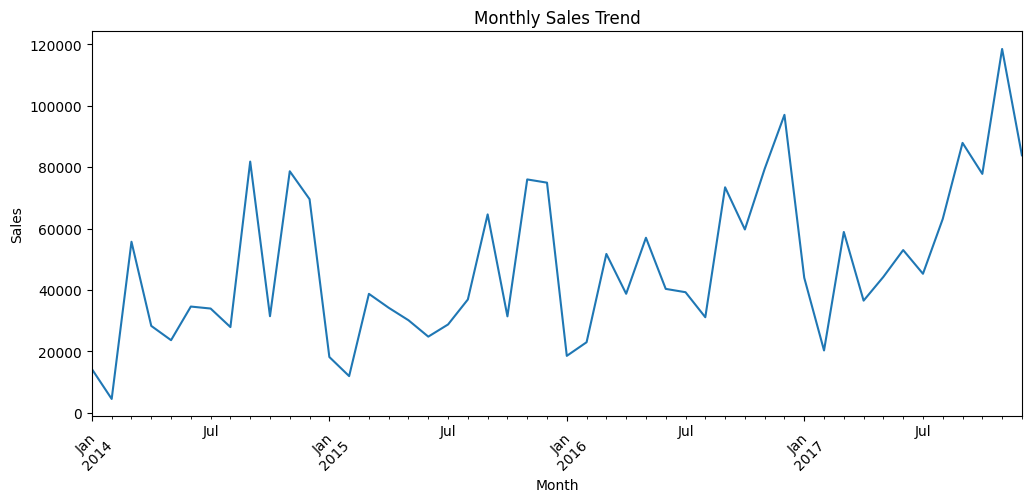

In [30]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.show()

### Observation

- Monthly sales fluctuate significantly throughout the period.
- Sales show several peaks and declines from month to month.
- Overall, sales performance appears stronger in 2017 compared with the earlier years.
- November 2017 recorded the highest monthly sales, at approximately 118,448.
- The variation in monthly sales suggests changing or seasonal sales patterns.

In [31]:
df['Quarter'] = df['order_date'].dt.to_period('Q')

In [32]:
df[['order_date', 'Quarter']].head()

,order_date,Quarter
0,2016-11-08,2016Q4
1,2016-11-08,2016Q4
2,2016-06-12,2016Q2
3,2015-10-11,2015Q4
4,2015-10-11,2015Q4


In [35]:
quarterly_sales = df.groupby('Quarter')['sales'].sum()
quarterly_sales

Quarter
2014Q1     74447.7960
2014Q2     86538.7596
2014Q3    143633.2123
2014Q4    179627.7302
2015Q1     68851.7386
2015Q2     89124.1870
2015Q3    130259.5752
2015Q4    182297.0082
2016Q1     93237.1810
2016Q2    136082.3010
2016Q3    143787.3622
2016Q4    236098.7538
2017Q1    123144.8602
2017Q2    133764.3720
2017Q3    196251.9560
2017Q4    280054.0670
Freq: Q-DEC, Name: sales, dtype: float64

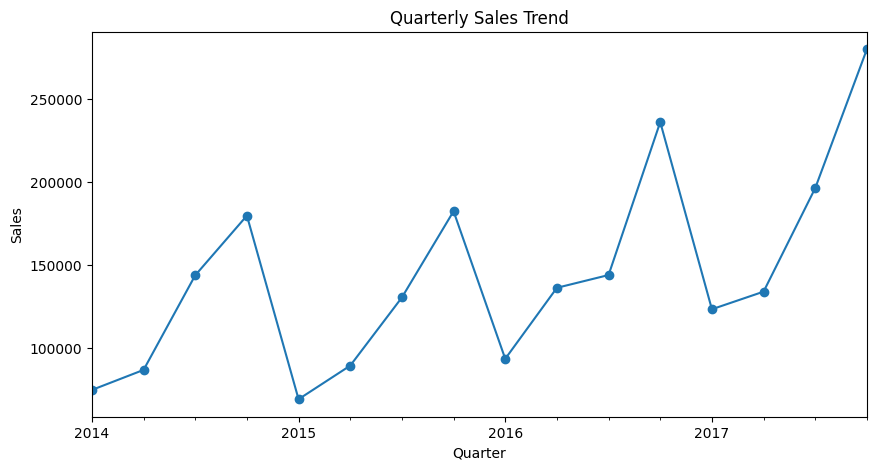

In [36]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Sales')

plt.show()

### Observation

- Quarterly sales fluctuate across the years.
- Overall, sales performance shows an increasing trend over time.
- Some quarters perform better than others, indicating seasonal variations in sales.
- The later years show stronger quarterly sales compared with the earlier years.
- This trend can help the business plan inventory and marketing activities for high-sales periods.

### Note

The dataset does not contain customer age and gender information. Therefore, customer segment and regional analysis were used as alternative customer profile analyses.

In [63]:
df['segment'].value_counts()

segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

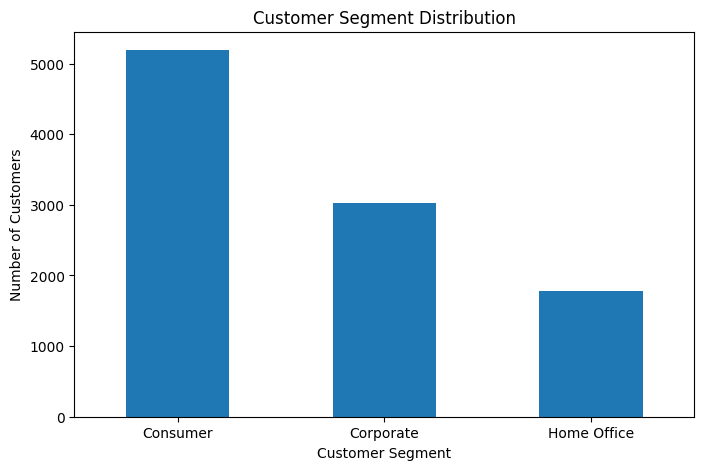

In [64]:
plt.figure(figsize=(8, 5))

df['segment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation

- The Consumer segment has the highest number of records with 5,191.
- The Corporate segment has 3,020 records.
- The Home Office segment has the lowest number of records with 1,783.
- Overall, the Consumer segment is the largest customer segment in the dataset.

In [39]:
df['region'].value_counts()

region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

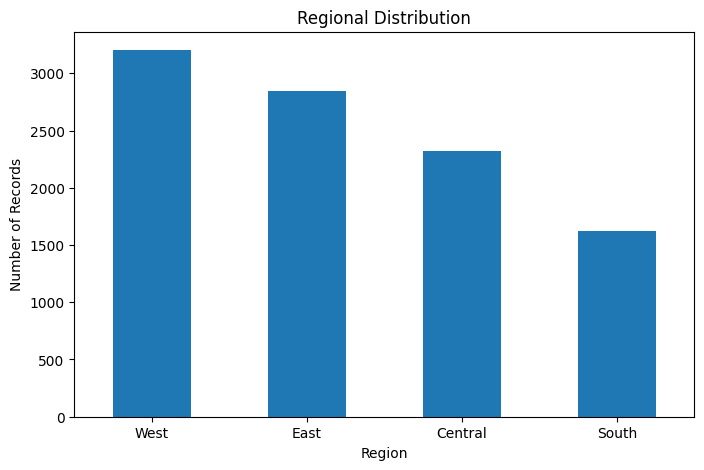

In [40]:
plt.figure(figsize=(8, 5))

df['region'].value_counts().plot(kind='bar')

plt.title('Regional Distribution')
plt.xlabel('Region')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)

plt.show()

### Observation

- The West region has the highest number of records with 3,203.
- The East region has 2,848 records.
- The Central region has 2,323 records.
- The South region has the lowest number of records with 1,620.
- Overall, the West region contributes the largest share of records in the dataset.

In [42]:
sales_by_segment = df.groupby('segment')['sales'].sum()
sales_by_segment

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

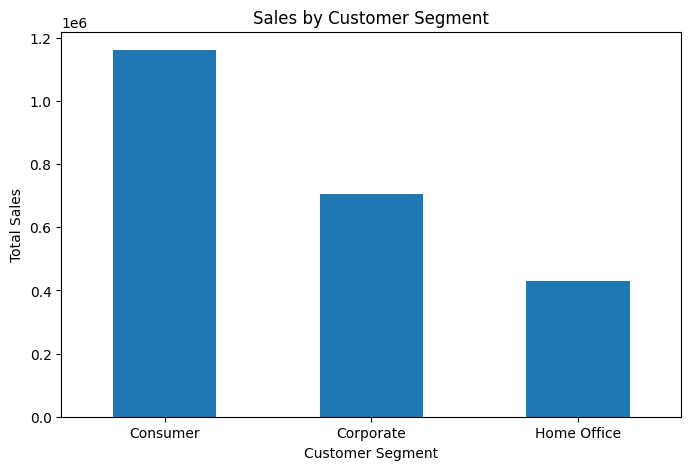

In [43]:
plt.figure(figsize=(8, 5))

sales_by_segment.plot(kind='bar')

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation

- The Consumer segment generates the highest total sales, approximately 1.16 million.
- The Corporate segment generates approximately 0.71 million in sales.
- The Home Office segment generates approximately 0.43 million in sales.
- The Consumer segment is the strongest customer segment in terms of total sales.
- This indicates that the Consumer segment is an important contributor to the company's overall revenue.

In [45]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False)


In [46]:
top_products.head(10)

product_name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: quantity, dtype: int64

In [56]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,row_id,postal_code,sales,quantity,discount,profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164


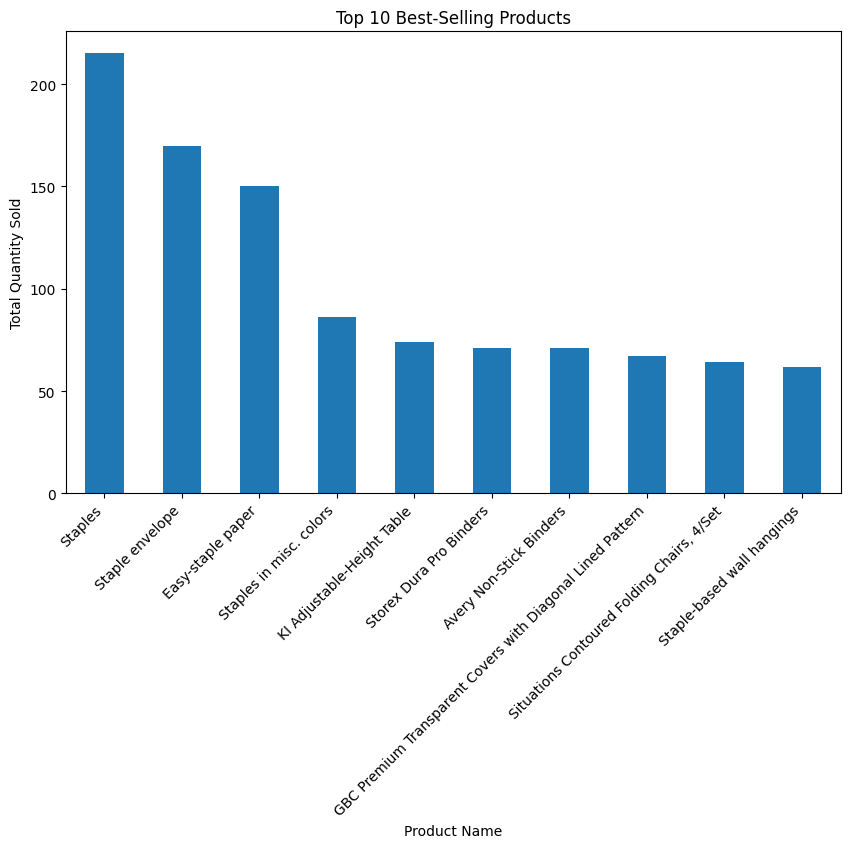

In [55]:
plt.figure(figsize=(10, 6))

top_products.head(10).plot(kind='bar')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')

plt.show()

### Observation

- Staples is the best-selling product based on total quantity sold.
- Staple Envelope and Easy-staple Paper are the next two highest-selling products.
- The top 10 products show that office-supply products make up a large portion of the highest-selling items.
- These products can be monitored closely to maintain sufficient inventory and avoid stock shortages.

## Revenue by Product Category

In [57]:
revenue_by_category = df.groupby('category')['sales'].sum()

revenue_by_category

category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64

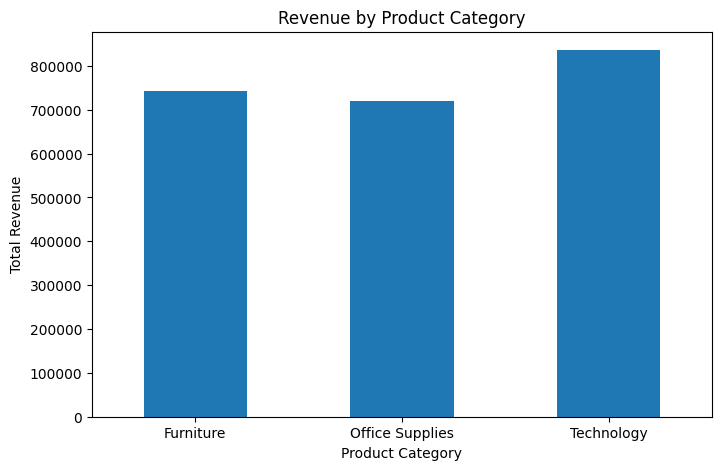

In [58]:
plt.figure(figsize=(8, 5))

revenue_by_category.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

### Observation

- Technology has the highest revenue at approximately 836,154.
- Furniture generates approximately 742,000 in revenue.
- Office Supplies generates approximately 719,047 in revenue.
- Technology is the strongest product category in terms of total revenue.
- The difference between the three categories is relatively moderate, with Technology leading the other categories.

In [49]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,row_id,postal_code,sales,quantity,discount,profit
row_id,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
postal_code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


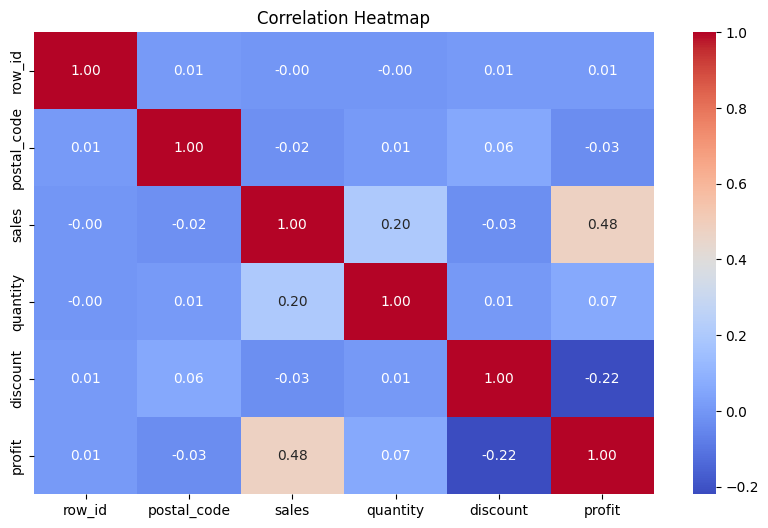

In [50]:
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Observation

- Sales and profit have a moderate positive correlation of approximately 0.48.
- Sales and quantity have a weak positive correlation of approximately 0.20.
- Discount and profit have a weak negative correlation of approximately -0.22.
- Quantity and profit have a very weak positive correlation of approximately 0.07.
- Most other numerical variables have correlations close to zero, indicating very weak linear relationships.

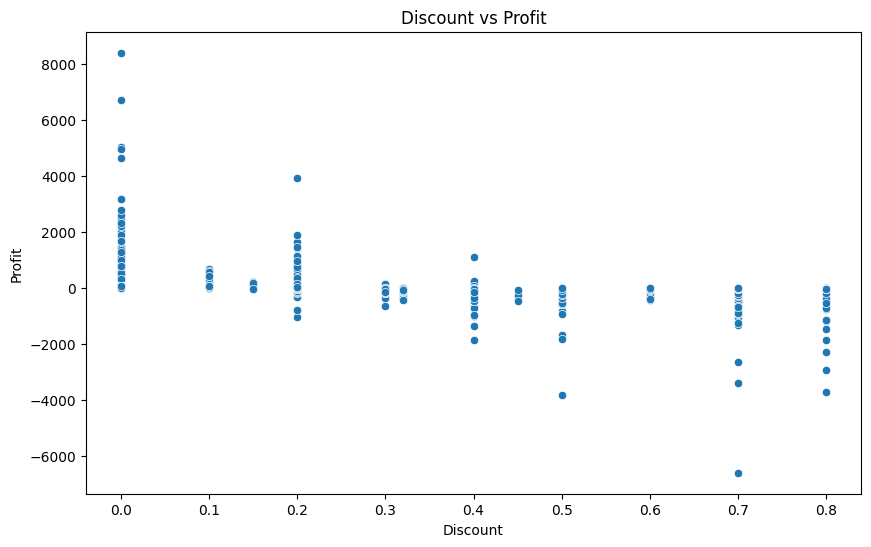

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='discount', y='profit')

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

### Observation

- The scatter plot shows that higher discount levels are generally associated with lower profit.
- At 0% discount, many records have positive profits.
- At higher discount levels such as 50%, 70%, and 80%, several records show negative profits.
- This suggests that excessive discounting may reduce profitability.
- However, discount alone does not determine profit because other factors such as product, quantity, and sales also affect profit.

## Additional Visualization: Discount vs Profit

This visualization is used to investigate whether discount levels are associated with changes in profit.
A scatter plot is used because it helps us observe the relationship between two numerical variables: discount and profit.

### Business Insight

The analysis suggests that the company should carefully manage high discount levels. 
Discounts can help increase sales, but excessive discounts may reduce profitability.
Therefore, discount strategies should be evaluated based on both sales performance and profit margins.

### Key Takeaway

The analysis indicates that maintaining a balance between offering discounts and achieving profitability is important. Higher discount levels are associated with more loss-making transactions, so the company should avoid excessive discounting and focus on profitable sales.

# Conclusion

The analysis of the retail sales dataset provided useful insights into sales performance, customer segments, products, and profitability.

### Key Findings

- Monthly sales fluctuate significantly, with several high-sales months.
- The Consumer segment has the highest number of records and total sales.
- The Technology category generates the highest total revenue.
- Sales and profit have a moderate positive correlation of approximately 0.48.
- Higher discount levels are associated with more loss-making transactions.

### Business Recommendations

1. **Control excessive discounts:**  
   The company should carefully review high discount levels because higher discounts are associated with more negative-profit transactions. Discount strategies should consider both sales and profitability.

2. **Focus on the Consumer segment:**  
   The Consumer segment generates the highest total sales. The company should use targeted promotions, loyalty programs, and marketing campaigns to retain and grow this customer segment.

3. **Plan inventory around high-sales periods:**  
   Since sales fluctuate significantly across months, the company should prepare inventory and marketing campaigns before high-sales periods to meet customer demand and avoid stock shortages.

4. **Improve weaker regional performance:**  
   The South region has the lowest number of records. The company should investigate the reasons for lower activity and consider targeted marketing strategies to improve performance.

5. **Focus on profitable products:**  
   The company should evaluate products using both sales and profit rather than quantity sold alone. Products with high sales but low profit should be reviewed for pricing and discount strategies.

### Final Takeaway

Overall, the analysis shows that increasing sales alone is not enough. The company should focus on profitable growth by managing discounts, strengthening high-performing customer segments, planning for seasonal demand, and improving weaker regions and products.